In [ ]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from langgraph.checkpoint.postgres.aio import AsyncPostgresSaver

from agents.primary.agent import build_primary_graph
from infrastructure.postgres import create_pool, open_postgres
from memory.embeddings import MemoryEmbeddingService
from memory.consolidation import DeterministicCandidateExtractor, LangMemCandidateExtractor
from memory.commit import MemoryCommitAdapter
from memory.verifier import DeterministicMemoryVerifier
from memory.worker import MemoryWorker
from repositories.long_term_memory import PostgresLongTermMemoryRepository
from repositories.result_store import ResultStoreRepository
from services.long_term_memory import MemoryService
from settings import get_settings
from utils.tracing import with_trace_config

settings = get_settings()
print("recall:", settings.long_term_memory_recall_enabled)
print("write:", settings.long_term_memory_write_enabled)

pool = create_pool(settings)
await pool.open(wait=True)

repo = ResultStoreRepository(pool)
memory_repo = PostgresLongTermMemoryRepository(pool)
memory_service = MemoryService(settings=settings, repository=memory_repo)

checkpointer = AsyncPostgresSaver(pool)
await checkpointer.setup()

graph = await build_primary_graph(
    checkpointer=checkpointer,
    repo=repo,
    memory_service=memory_service,
)

recall: True
write: True


  + Exception Group Traceback (most recent call last):
  |   File "C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py", line 3575, in run_code
  |     await eval(code_obj, self.user_global_ns, self.user_ns)
  |   File "C:\Users\Admin\AppData\Local\Temp\ipykernel_8380\2355732503.py", line 37, in <module>
  |     graph = await build_primary_graph(
  |             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  |   File "e:\Travel Agent\customer-support-agent\src\agents\primary\agent.py", line 329, in build_primary_graph
  |     await asyncio.gather(
  |   File "e:\Travel Agent\customer-support-agent\src\agents\hotel\agent.py", line 24, in build_hotel_graph
  |     hotel_tools = await get_hotel_tools()
  |                   ^^^^^^^^^^^^^^^^^^^^^^^
  |   File "c:\Program Files\Python312\Lib\site-packages\langsmith\run_helpers.py", line 563, in async_wrapper
  |     function_result = await asyncio.create_task(  # type: ignore[call-arg]
  |                       ^^^^

: 

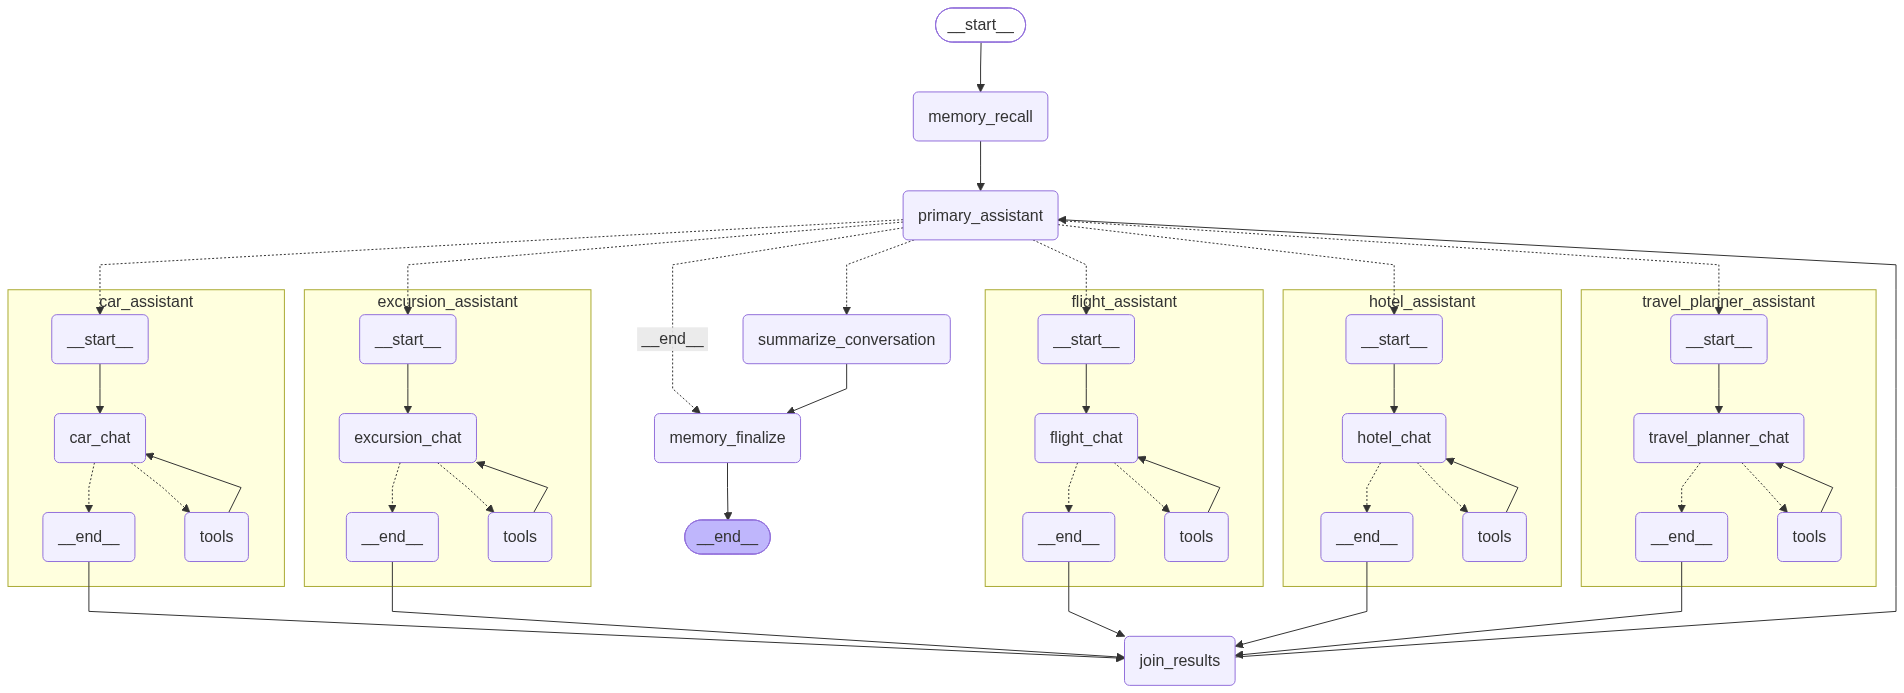

In [ ]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [ ]:
user_id = "user-a"
thread_id = "ltm-t1"

config = with_trace_config(
    {"configurable": {"thread_id": thread_id, "user_id": user_id}},
    run_name="ltm_test_write",
    tags=["ltm"],
    metadata={"thread_id": thread_id, "user_id": user_id},
)

result = await graph.ainvoke(
    {
        "messages": ("user", "Hãy nhớ rằng tôi thích khách sạn boutique gần biển"),
        "user_id": user_id,
        "thread_id": thread_id,
    },
    config,
)

print("memory_job_id:", result.get("memory_job_id"))
print("memory_context:", result.get("memory_context"))
print("recalled_ids:", result.get("recalled_memory_ids"))

memory_job_id: 2fb90fef-4ddc-4c99-b398-be79d306a685
memory_context: 
recalled_ids: []


In [ ]:
worker = MemoryWorker(
    pool=pool,
    settings=settings,
    repository=memory_repo,
    commit_adapter=MemoryCommitAdapter(
        repository=memory_repo,
        verifier=DeterministicMemoryVerifier(),
    ),
)
print(await worker.process_next())

async with pool.connection() as conn:
    jobs = await (await conn.execute(
        "SELECT job_id, status, attempts, error_summary FROM memory_jobs ORDER BY created_at DESC LIMIT 5"
    )).fetchall()
    mems = await (await conn.execute(
        "SELECT memory_id, memory_text, category, status, user_id FROM long_term_memories ORDER BY created_at DESC LIMIT 5"
    )).fetchall()

print("jobs:", [dict(r) for r in jobs])
print("memories:", [dict(r) for r in mems])
# worker = MemoryWorker(
#     pool=pool,
#     settings=settings,
#     repository=memory_repo,
#     commit_adapter=MemoryCommitAdapter(
#         repository=memory_repo,
#         verifier=DeterministicMemoryVerifier(),
#     ),
# )

# # Chạy vòng lặp cho đến khi hết sạch job pending
# while True:
#     result = await worker.process_next()
#     if not result.processed:
#         print("Đã xử lý hết hàng đợi!")
#         break
#     print(f"Đã xử lý job: {result.job_id} - status: {result.status}")

Key '$defs' is not supported in schema, ignoring
Key 'additionalProperties' is not supported in schema, ignoring


WorkerResult(processed=True, job_id='2fb90fef-4ddc-4c99-b398-be79d306a685', status='completed', candidates=1, error=None)
jobs: [{'job_id': UUID('2fb90fef-4ddc-4c99-b398-be79d306a685'), 'status': 'completed', 'attempts': 1, 'error_summary': None}, {'job_id': UUID('5f0c54b3-0721-4574-a468-305e758b843f'), 'status': 'skipped', 'attempts': 1, 'error_summary': None}, {'job_id': UUID('3a80f114-ab32-4efa-8bfd-da4e73bbdfae'), 'status': 'completed', 'attempts': 1, 'error_summary': None}, {'job_id': UUID('e3cd5d79-420a-49a9-9345-3c4a6dbbb362'), 'status': 'failed', 'attempts': 3, 'error_summary': "Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelan

In [ ]:
thread_id = "ltm-t2"

# user_id = "u-test"
config = with_trace_config(
    {"configurable": {"thread_id": thread_id, "user_id": user_id}},
    run_name="ltm_test_recall",
    tags=["ltm"],
    metadata={"thread_id": thread_id, "user_id": user_id},
)

result = await graph.ainvoke(
    {
        "messages": ("user", "Tìm khách sạn ở Nha Trang cho tôi"),
        "user_id": user_id,
        "thread_id": thread_id,
    },
    config,
)

print("memory_context:", result.get("memory_context"))
print("recalled_ids:", result.get("recalled_memory_ids"))

memory_context: [9eb63caa-bcfa-4930-8d81-2ad0ce9599a0] Thích khách sạn boutique gần biển
recalled_ids: ['9eb63caa-bcfa-4930-8d81-2ad0ce9599a0']


In [2]:
# Cell 1: (Adjusted) Imports và Setup
# ... (your existing imports) ...

from settings import get_settings, Settings
# ... (your existing logging setup) ...

# Lấy các giá trị mặc định từ get_settings()
# Sau đó tạo một Settings instance mới với các giá trị được override
base_settings = get_settings() # Lấy một bản sao của settings hiện tại

# Tạo một instance Settings MỚI với các giá trị được override
# Sử dụng dataclasses.replace để thay thế các trường mong muốn
from dataclasses import replace

settings = replace(
    base_settings,
    long_term_memory_recall_enabled=True,
    long_term_memory_write_enabled=True,
    long_term_memory_vector_search_enabled=True,
    long_term_memory_vector_fallback_enabled=True,
    long_term_memory_extractor="deterministic",  # ổn định hơn cho notebook test; đổi "langmem" khi cần
    long_term_memory_sync_finalize=True, # Quan trọng: để job xử lý ngay
    # Các giá trị này nên được lấy từ .env hoặc base_settings nếu chúng đã đúng
    long_term_memory_embedding_model=os.getenv("LONG_TERM_MEMORY_EMBEDDING_MODEL", "models/gemini-embedding-001"),
    long_term_memory_vector_dims=int(os.getenv("LONG_TERM_MEMORY_VECTOR_DIMS", 3072)),
    long_term_memory_vector_distance_threshold=float(os.getenv("LONG_TERM_MEMORY_VECTOR_DISTANCE_THRESHOLD", 0.35)),
)


print("Current LTM Settings:")
print(f"  Recall Enabled: {settings.long_term_memory_recall_enabled}")
print(f"  Write Enabled: {settings.long_term_memory_write_enabled}")
print(f"  Vector Search Enabled: {settings.long_term_memory_vector_search_enabled}")
print(f"  Extractor: {settings.long_term_memory_extractor}")
print(f"  Sync Finalize: {settings.long_term_memory_sync_finalize}")
print(f"  Embedding Model: {settings.long_term_memory_embedding_model}")
print(f"  Vector Dims: {settings.long_term_memory_vector_dims}")

# Khởi tạo các service cần thiết
# ... (phần code khởi tạo service của bạn) ...

Current LTM Settings:
  Recall Enabled: True
  Write Enabled: True
  Vector Search Enabled: True
  Extractor: deterministic
  Sync Finalize: True
  Embedding Model: models/gemini-embedding-001
  Vector Dims: 3072


In [3]:
# Cell 2: Khởi tạo DB và Services
async def setup_memory_services():
    global pool, repository, embedding_service, commit_adapter, memory_worker, memory_service

    # Postgres connection pool
    pool = create_pool(settings)
    await pool.open(wait=True)

    # Repository
    repository = PostgresLongTermMemoryRepository(pool)

    # Embedding Service
    embedding_service = MemoryEmbeddingService(settings=settings)

    # Commit Adapter
    # Hiện tại DeterministicMemoryVerifier là đủ cho ví dụ
    verifier = DeterministicMemoryVerifier()
    commit_adapter = MemoryCommitAdapter(
        repository=repository,
        verifier=verifier,
        embedding_service=embedding_service, # Truyền embedding_service vào commit adapter
    )

    # Candidate Extractor
    if settings.long_term_memory_extractor == "langmem":
        extractor = LangMemCandidateExtractor(model=settings.long_term_memory_langmem_model)
    else:
        extractor = DeterministicCandidateExtractor() # Giả định DeterministicCandidateExtractor tồn tại

    # Memory Worker (Job Processor)
    memory_worker = MemoryWorker(
        pool=pool,
        settings=settings,
        repository=repository,
        commit_adapter=commit_adapter,
        extractor=extractor,
    )

    # Memory Service
    memory_service = MemoryService(
        settings=settings,
        repository=repository,
        processor=memory_worker, # Truyền worker làm processor cho sync finalize
        embedding_service=embedding_service, # Truyền embedding service cho recall
    )
    print("Memory services initialized.")

await setup_memory_services()

Memory services initialized.


In [ ]:
# Cell 3: Bộ test LTM đa trường hợp
import uuid
from dataclasses import replace
from langchain_core.messages import HumanMessage, AIMessage
from memory.long_term import MemoryFamily

PASS, FAIL = [], []

def _ok(name: str, detail: str = ""):
    PASS.append(name)
    print(f"  ✅ PASS: {name}" + (f" — {detail}" if detail else ""))

def _fail(name: str, detail: str = ""):
    FAIL.append(name)
    print(f"  ❌ FAIL: {name}" + (f" — {detail}" if detail else ""))

async def _job_status(job_id: str) -> dict | None:
    async with pool.connection() as conn:
        return await (
            await conn.execute(
                "SELECT status, error_summary FROM memory_jobs WHERE job_id = %s",
                (job_id,),
            )
        ).fetchone()

async def _save_and_finalize(user_id: str, thread_id: str, messages, *, final_message_id: str | None = None):
    msg_id = final_message_id or f"msg-{uuid.uuid4().hex[:10]}"
    job = await memory_service.enqueue_final_turn(
        user_id=user_id,
        thread_id=thread_id,
        final_message_id=msg_id,
        checkpoint_id=f"chk-{uuid.uuid4().hex[:8]}",
        messages=messages,
    )
    if job and job.created:
        row = await _job_status(job.job_id)
        if row and row["status"] == "pending":
            await memory_service._processor.process_job(job.job_id)
            row = await _job_status(job.job_id)
        return job, row
    if job and not job.created:
        return job, await _job_status(job.job_id)
    return None, None

async def run_ltm_tests():
    if memory_service._processor is None:
        print("⚠️ Chạy lại Cell 2 trước (processor=None).")
        return

    print("=" * 60)
    print("LTM multi-case tests")
    print(f"extractor={memory_service._settings.long_term_memory_extractor}")
    print(f"sync_finalize={memory_service._settings.long_term_memory_sync_finalize}")
    print("=" * 60)

    # ---------- Case 1: Hotel preference save + recall ----------
    print("\n[1] Hotel preference save + recall")
    u1 = f"test-hotel-{uuid.uuid4().hex[:8]}"
    t1 = f"thread-{uuid.uuid4().hex[:8]}"
    job, row = await _save_and_finalize(
        u1, t1,
        [
            HumanMessage(content="Tôi đang tìm chỗ ở Đà Nẵng."),
            AIMessage(content="Bạn thích loại khách sạn nào?"),
            HumanMessage(content="Tôi thích ở khách sạn gần biển, có hồ bơi và view đẹp."),
        ],
    )
    recall = await memory_service.recall(user_id=u1, query="khách sạn gần biển hồ bơi")
    if job and row and row["status"] in {"completed", "skipped"} and recall.memories:
        _ok("hotel_save_recall", f"status={row['status']}, n={len(recall.memories)}")
        for m in recall.memories:
            print(f"    → {m.category}: {m.memory_text}")
    elif job and row and row["status"] == "completed" and not recall.memories:
        _fail("hotel_save_recall", "job completed nhưng recall rỗng")
    else:
        _fail("hotel_save_recall", f"job={job}, status={row}")

    # ---------- Case 2: Flight preference ----------
    print("\n[2] Flight preference")
    u2 = f"test-flight-{uuid.uuid4().hex[:8]}"
    job, row = await _save_and_finalize(
        u2, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi ưu tiên bay thẳng, không thích chuyến bay nối chuyến.")],
    )
    recall = await memory_service.recall(user_id=u2, query="ưu tiên chuyến bay thẳng")
    if recall.memories:
        _ok("flight_preference", f"n={len(recall.memories)}, category={recall.memories[0].category}")
        for m in recall.memories:
            print(f"    → {m.category}: {m.memory_text}")
    else:
        _fail("flight_preference", f"status={row}, memories=0")

    # ---------- Case 3: Car preference ----------
    print("\n[3] Car preference")
    u3 = f"test-car-{uuid.uuid4().hex[:8]}"
    job, row = await _save_and_finalize(
        u3, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích thuê xe tự lái, xe số tự động.")],
    )
    recall = await memory_service.recall(user_id=u3, query="thuê xe tự lái")
    if recall.memories:
        _ok("car_preference", f"n={len(recall.memories)}, category={recall.memories[0].category}")
    else:
        _fail("car_preference", f"status={row}")

    # ---------- Case 4: Non-durable message → skip / no memory ----------
    print("\n[4] Non-durable chitchat (không nên lưu)")
    u4 = f"test-skip-{uuid.uuid4().hex[:8]}"
    job, row = await _save_and_finalize(
        u4, f"thread-{uuid.uuid4().hex[:8]}",
        [
            HumanMessage(content="Xin chào"),
            AIMessage(content="Chào bạn!"),
            HumanMessage(content="Hôm nay trời đẹp quá"),
        ],
    )
    recall = await memory_service.recall(user_id=u4, query="trời đẹp")
    if not recall.memories and row and row["status"] in {"skipped", "completed"}:
        _ok("non_durable_skip", f"status={row['status']}, memories=0")
    elif not recall.memories:
        _ok("non_durable_skip", f"không có memory (status={row})")
    else:
        _fail("non_durable_skip", f"không nên lưu nhưng có {len(recall.memories)} memory")

    # ---------- Case 5: Idempotency ----------
    print("\n[5] Idempotency — enqueue 2 lần cùng final_message_id")
    u5 = f"test-idem-{uuid.uuid4().hex[:8]}"
    t5 = f"thread-{uuid.uuid4().hex[:8]}"
    msgs = [HumanMessage(content="Tôi thích khách sạn boutique yên tĩnh.")]
    mid = f"msg-idem-{uuid.uuid4().hex[:8]}"
    job_a, _ = await _save_and_finalize(u5, t5, msgs, final_message_id=mid)
    job_b, _ = await _save_and_finalize(u5, t5, msgs, final_message_id=mid)
    if job_a and job_b and job_a.job_id == job_b.job_id and job_a.created and not job_b.created:
        _ok("idempotency", f"same job_id={job_a.job_id}")
    else:
        _fail("idempotency", f"a.created={getattr(job_a,'created',None)}, b.created={getattr(job_b,'created',None)}")

    # ---------- Case 6: User isolation ----------
    print("\n[6] User isolation — user A không thấy memory của user B")
    u_a = f"test-iso-a-{uuid.uuid4().hex[:8]}"
    u_b = f"test-iso-b-{uuid.uuid4().hex[:8]}"
    await _save_and_finalize(
        u_a, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích khách sạn 5 sao gần biển Mỹ Khê.")],
    )
    recall_b = await memory_service.recall(user_id=u_b, query="khách sạn biển Mỹ Khê")
    if not recall_b.memories:
        _ok("user_isolation", "user B không thấy memory của A")
    else:
        _fail("user_isolation", f"leak {len(recall_b.memories)} memories sang user B")

    # ---------- Case 7: Write disabled ----------
    print("\n[7] Write disabled → không enqueue")
    old_settings = memory_service._settings
    memory_service._settings = replace(old_settings, long_term_memory_write_enabled=False)
    try:
        job = await memory_service.enqueue_final_turn(
            user_id=f"test-nowrite-{uuid.uuid4().hex[:8]}",
            thread_id=f"thread-{uuid.uuid4().hex[:8]}",
            final_message_id=f"msg-{uuid.uuid4().hex[:8]}",
            checkpoint_id=None,
            messages=[HumanMessage(content="Tôi thích bay thẳng.")],
        )
        if job is None:
            _ok("write_disabled", "enqueue trả về None")
        else:
            _fail("write_disabled", f"vẫn tạo job={job.job_id}")
    finally:
        memory_service._settings = old_settings

    # ---------- Case 8: Recall disabled ----------
    print("\n[8] Recall disabled → context rỗng")
    try:
        u8 = f"test-norecall-{uuid.uuid4().hex[:8]}"
        await _save_and_finalize(
            u8, f"thread-{uuid.uuid4().hex[:8]}",
            [HumanMessage(content="Tôi thích khách sạn gần biển.")],
        )
        memory_service._settings = replace(old_settings, long_term_memory_recall_enabled=False)
        recall = await memory_service.recall(user_id=u8, query="khách sạn biển")
        if not recall.memories and recall.memory_context == "":
            _ok("recall_disabled")
        else:
            _fail("recall_disabled", f"n={len(recall.memories)}")
    finally:
        memory_service._settings = old_settings

    # ---------- Case 9: Empty user / empty query ----------
    print("\n[9] Empty user / empty query → không recall")
    r1 = await memory_service.recall(user_id="", query="khách sạn")
    r2 = await memory_service.recall(user_id=u1, query="   ")
    if not r1.memories and not r2.memories:
        _ok("empty_user_or_query")
    else:
        _fail("empty_user_or_query")

    # ---------- Case 10: Multiple preferences same user ----------
    print("\n[10] Nhiều preference cùng 1 user")
    u10 = f"test-multi-{uuid.uuid4().hex[:8]}"
    await _save_and_finalize(
        u10, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích khách sạn gần biển.")],
    )
    await _save_and_finalize(
        u10, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi ưu tiên bay thẳng.")],
    )
    recall = await memory_service.recall(user_id=u10, query="khách sạn và chuyến bay")
    if len(recall.memories) >= 1:
        _ok("multi_preference", f"n={len(recall.memories)}")
        for m in recall.memories:
            print(f"    → {m.category}: {m.memory_text}")
    else:
        _fail("multi_preference", "không tìm thấy memory")

    # ---------- Case 11: Family filter ----------
    print("\n[11] Recall với family filter")
    recall_pref = await memory_service.recall(
        user_id=u10,
        query="du lịch",
        families=(MemoryFamily.TRAVEL_PREFERENCES,),
    )
    _ok("family_filter", f"n={len(recall_pref.memories)}")

    # ---------- Case 12: Conflicting preference ----------
    print("\n[12] Preference xung đột / cập nhật")
    u12 = f"test-conflict-{uuid.uuid4().hex[:8]}"
    await _save_and_finalize(
        u12, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích khách sạn gần biển.")],
    )
    await _save_and_finalize(
        u12, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi không thích khách sạn gần biển, tôi thích ở trung tâm thành phố.")],
    )
    # Lấy toàn bộ active memories (không phụ thuộc semantic rank)
    from repositories.long_term_memory import MemorySearchFilters as _MSF
    active = [
        m for m in await repository.search_active_memories(
            _MSF(user_id=u12, families=tuple(MemoryFamily), query=None, limit=50)
        )
        if m.is_active
    ]
    texts = [m.memory_text for m in active]
    old_still_active = any(
        ("khách sạn gần biển" in t.lower())
        and ("không thích" not in t.lower())
        and ("trung tâm" not in t.lower())
        for t in texts
    )
    new_present = any(
        ("không thích" in t.lower()) or ("trung tâm" in t.lower())
        for t in texts
    )
    print(f"    active_count={len(active)}")
    for m in active:
        print(f"    → {m.category}: {m.memory_text}")
    if len(active) != 1:
        _fail(
            "conflict_update",
            f"kỳ vọng đúng 1 active sau supersede, actual n={len(active)}; old_still_active={old_still_active}",
        )
    elif old_still_active:
        _fail("conflict_update", "memory cũ vẫn active (chưa supersede)")
    elif not new_present:
        _fail("conflict_update", "không thấy memory mới (không thích / trung tâm)")
    else:
        _ok("conflict_update", f"n=1, superseded OK — {active[0].memory_text!r}")

    # ---------- Case 13: Missing user/thread on write ----------
    print("\n[13] Write thiếu user_id/thread_id → None")
    job = await memory_service.enqueue_final_turn(
        user_id="",
        thread_id="thread-x",
        final_message_id="msg-x",
        checkpoint_id=None,
        messages=[HumanMessage(content="Tôi thích bay thẳng.")],
    )
    if job is None:
        _ok("missing_user_on_write")
    else:
        _fail("missing_user_on_write", f"job={job.job_id}")

    # ---------- Case 14–24: Trùng / mâu thuẫn (unit + e2e) ----------
    from memory.consolidation import (
        calculate_transition,
        extract_candidate_memories,
        TransitionAction,
    )
    from memory.long_term import (
        MemoryCategory,
        MemoryDomain,
        TravelMemory,
    )
    from repositories.long_term_memory import MemorySearchFilters

    def _mem(text: str, *, category=MemoryCategory.HOTEL_PREFERENCE, domain=MemoryDomain.HOTEL, mid=None):
        return TravelMemory(
            memory_id=mid or f"mem-{uuid.uuid4().hex[:8]}",
            user_id="unit-user",
            memory_text=text,
            category=category,
            domain=domain,
            evidence_text=text,
            source_thread_id="unit-thread",
        )

    async def _active_count(user_id: str) -> int:
        memories = await repository.search_active_memories(
            MemorySearchFilters(
                user_id=user_id,
                families=tuple(MemoryFamily),
                query=None,
                limit=50,
            )
        )
        return len([m for m in memories if m.is_active])

    async def _latest_audit(user_id: str) -> dict | None:
        async with pool.connection() as conn:
            return await (
                await conn.execute(
                    """
                    SELECT decision, proposed_transition, affected_memory_ids
                    FROM memory_audit_records
                    WHERE user_id = %s
                    ORDER BY created_at DESC
                    LIMIT 1
                    """,
                    (user_id,),
                )
            ).fetchone()

    print("\n[14] Unit: duplicate exact → NOOP")
    existing = [_mem("khách sạn gần biển", mid="e1")]
    tr = calculate_transition(_mem("khách sạn gần biển", mid="c1"), existing)
    if tr.action == TransitionAction.NOOP and "duplicate" in " ".join(tr.reasons):
        _ok("unit_duplicate_noop", f"reasons={tr.reasons}")
    else:
        _fail("unit_duplicate_noop", f"action={tr.action}, reasons={tr.reasons}")

    print("\n[15] Unit: duplicate sau normalize (punctuation/case) → NOOP")
    existing = [_mem("Khách sạn gần biển.", mid="e2")]
    tr = calculate_transition(_mem("khách sạn gần biển!", mid="c2"), existing)
    if tr.action == TransitionAction.NOOP:
        _ok("unit_duplicate_normalized")
    else:
        _fail("unit_duplicate_normalized", f"action={tr.action}")

    print("\n[16] Unit: mâu thuẫn cùng category/domain → SUPERSEDE")
    existing = [_mem("thích khách sạn gần biển", mid="e3")]
    tr = calculate_transition(_mem("không thích khách sạn gần biển", mid="c3"), existing)
    if tr.action == TransitionAction.SUPERSEDE and tr.existing_memory_id == "e3":
        _ok("unit_conflict_supersede", f"reasons={tr.reasons}")
    else:
        _fail("unit_conflict_supersede", f"action={tr.action}, existing={tr.existing_memory_id}")

    print("\n[17] Unit: khác category → INSERT (không coi là conflict)")
    existing = [
        _mem(
            "thích bay thẳng",
            category=MemoryCategory.FLIGHT_PREFERENCE,
            domain=MemoryDomain.FLIGHT,
            mid="e4",
        )
    ]
    tr = calculate_transition(
        _mem(
            "không thích bay thẳng",
            category=MemoryCategory.HOTEL_PREFERENCE,
            domain=MemoryDomain.HOTEL,
            mid="c4",
        ),
        existing,
    )
    if tr.action == TransitionAction.INSERT:
        _ok("unit_diff_category_insert")
    else:
        _fail("unit_diff_category_insert", f"action={tr.action}")

    print("\n[18] Unit: cùng category nhưng không conflict → INSERT")
    existing = [_mem("thích khách sạn gần biển", mid="e5")]
    tr = calculate_transition(_mem("thích khách sạn có hồ bơi", mid="c5"), existing)
    if tr.action == TransitionAction.INSERT:
        _ok("unit_same_category_compatible_insert")
    else:
        _fail("unit_same_category_compatible_insert", f"action={tr.action}")

    print("\n[19] E2E: lưu trùng 2 lần → không tăng số active memory")
    u19 = f"test-dup-{uuid.uuid4().hex[:8]}"
    msg_dup = [HumanMessage(content="Tôi thích khách sạn gần biển.")]
    await _save_and_finalize(u19, f"thread-{uuid.uuid4().hex[:8]}", msg_dup)
    n1 = await _active_count(u19)
    await _save_and_finalize(u19, f"thread-{uuid.uuid4().hex[:8]}", msg_dup)
    n2 = await _active_count(u19)
    audit = await _latest_audit(u19)
    decision = audit["decision"] if audit else None
    if n1 >= 1 and n2 == n1:
        _ok("e2e_duplicate_no_growth", f"active={n2}, last_decision={decision}")
    else:
        _fail("e2e_duplicate_no_growth", f"n1={n1}, n2={n2}, decision={decision}")

    print("\n[20] E2E: mâu thuẫn → supersede (active không tăng vô hạn)")
    u20 = f"test-conf-{uuid.uuid4().hex[:8]}"
    await _save_and_finalize(
        u20, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích khách sạn gần biển.")],
    )
    n_before = await _active_count(u20)
    await _save_and_finalize(
        u20, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi không thích khách sạn gần biển nữa.")],
    )
    n_after = await _active_count(u20)
    audit = await _latest_audit(u20)
    decision = audit["decision"] if audit else None
    recall = await memory_service.recall(user_id=u20, query="khách sạn gần biển")
    texts = " | ".join(m.memory_text.lower() for m in recall.memories)
    if decision in {"approve", "noop"} and n_before >= 1 and n_after >= 1:
        detail = f"before={n_before}, after={n_after}, decision={decision}, texts={texts!r}"
        if n_after == n_before:
            _ok("e2e_conflict_supersede", detail)
        else:
            _fail("e2e_conflict_supersede", f"active tăng — {detail}")
        for m in recall.memories:
            print(f"    → {m.category}: {m.memory_text}")
    else:
        _fail("e2e_conflict_supersede", f"before={n_before}, after={n_after}, decision={decision}")

    print("\n[21] E2E: 2 preference khác domain → cả hai được giữ")
    u21 = f"test-both-{uuid.uuid4().hex[:8]}"
    await _save_and_finalize(
        u21, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi thích khách sạn gần biển.")],
    )
    await _save_and_finalize(
        u21, f"thread-{uuid.uuid4().hex[:8]}",
        [HumanMessage(content="Tôi ưu tiên bay thẳng.")],
    )
    n21 = await _active_count(u21)
    if n21 >= 2:
        _ok("e2e_compatible_multi_insert", f"active={n21}")
    elif n21 == 1:
        _ok("e2e_compatible_multi_insert", f"active=1 (extractor gộp/giới hạn)")
    else:
        _fail("e2e_compatible_multi_insert", f"active={n21}")

    print("\n[22] Unit: extract + transition trên hội thoại trùng")
    msgs = [{"type": "human", "content": "Tôi thích khách sạn gần biển."}]
    cands = extract_candidate_memories(msgs, user_id="pipe", thread_id="t1")
    if not cands:
        _fail("pipeline_duplicate", "extractor không tạo candidate")
    else:
        first = cands[0]
        existing_db = [
            TravelMemory(
                memory_id="existing-1",
                user_id="pipe",
                memory_text=first.memory_text,
                category=first.category,
                domain=first.domain,
                evidence_text=first.evidence_text,
                source_thread_id="t0",
            )
        ]
        tr = calculate_transition(first, existing_db)
        if tr.action == TransitionAction.NOOP:
            _ok("pipeline_duplicate", f"text={first.memory_text!r}")
        else:
            _fail("pipeline_duplicate", f"action={tr.action}, text={first.memory_text!r}")

    print("\n[23] Unit: conflict khi memory_text còn marker thích/không thích")
    old_tm = _mem("thích khách sạn gần biển", mid="existing-2")
    new_tm = _mem("không thích khách sạn gần biển", mid="cand-2")
    tr = calculate_transition(new_tm, [old_tm])
    if tr.action == TransitionAction.SUPERSEDE:
        _ok("pipeline_conflict_markers", f"{old_tm.memory_text!r} → {new_tm.memory_text!r}")
    else:
        _fail("pipeline_conflict_markers", f"action={tr.action}, reasons={tr.reasons}")

    print("\n[24] Observability: deterministic extract có giữ tín hiệu conflict không?")
    old_c = extract_candidate_memories(
        [{"type": "human", "content": "Tôi thích khách sạn gần biển."}],
        user_id="pipe2",
        thread_id="t1",
    )
    new_c = extract_candidate_memories(
        [{"type": "human", "content": "Tôi không thích khách sạn gần biển."}],
        user_id="pipe2",
        thread_id="t2",
    )
    if not old_c or not new_c:
        _fail("extract_conflict_signal", f"old={len(old_c)}, new={len(new_c)}")
    else:
        tr = calculate_transition(new_c[0], [
            TravelMemory(
                memory_id="existing-3",
                user_id="pipe2",
                memory_text=old_c[0].memory_text,
                category=old_c[0].category,
                domain=old_c[0].domain,
                evidence_text=old_c[0].evidence_text,
                source_thread_id="t1",
            )
        ])
        detail = f"old={old_c[0].memory_text!r}, new={new_c[0].memory_text!r}, action={tr.action}"
        if tr.action == TransitionAction.SUPERSEDE:
            _ok("extract_conflict_signal", detail)
        else:
            print(f"  ⚠️  INFO: extract chưa giữ đủ marker conflict — {detail}")
            print("      (calculate_transition vẫn đúng nếu memory_text còn 'thích'/'không thích')")
            _ok("extract_conflict_signal_observed_gap", detail)

    # ---------- Summary ----------
    print("\n" + "=" * 60)
    print(f"SUMMARY: {len(PASS)} passed, {len(FAIL)} failed / {len(PASS)+len(FAIL)} total")
    if FAIL:
        print("Failed cases:", ", ".join(FAIL))
    print("=" * 60)

await run_ltm_tests()


LTM multi-case tests
extractor=deterministic
sync_finalize=True

[1] Hotel preference save + recall
[Worker] process_job result: WorkerResult(processed=True, job_id='de2b42a0-1fe7-4fe2-bf2b-a0221f1d930f', status='completed', candidates=1, error=None)
  ✅ PASS: hotel_save_recall — status=completed, n=1
    → hotel_preference: thích ở khách sạn gần biển, có hồ bơi và view đẹp

[2] Flight preference
[Worker] process_job result: WorkerResult(processed=True, job_id='0f1b437a-b304-49af-b2f1-64cc21fa3b1f', status='completed', candidates=1, error=None)
  ✅ PASS: flight_preference — n=1, category=flight_preference
    → flight_preference: ưu tiên bay thẳng, không thích chuyến bay nối chuyến

[3] Car preference
[Worker] process_job result: WorkerResult(processed=True, job_id='efcfde3c-f270-4e82-94ff-59e8b36fbd36', status='completed', candidates=1, error=None)
  ✅ PASS: car_preference — n=1, category=car_preference

[4] Non-durable chitchat (không nên lưu)
[Worker] process_job result: WorkerResul